In [ ]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
# 모델 초기화
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", google_api_key=os.getenv("GEMINI_API_KEY")
)
model.invoke("안녕")

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 무엇을 도와드릴까요?', 'extras': {'signature': 'EjQKMgERTTIPsXVNRpxJzt/r9Il48Qh/zFpvU6MOq7WHos2gKMjNrcJWjhZ3nILbp+fA1Xy1'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe53c-d593-7ef2-b3b4-d8ef64ee6870-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 8, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}})

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
      messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
      'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
      (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """

    messages: Annotated[list[str], add_messages]


# StateGraph 클래스를 사용하여 State 타입의 그래프 생성
graph_builder = StateGraph(State)

In [5]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper


# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f"{timezone} ({location}) 현재시각 {now}"
        print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"


@tool
def get_web_search(query: str, search_period: str) -> str:
    """웹 검색을 수행하는 함수.
    Args:
        query (str): 검색어
        search_period (str): 검색 기간(e.g., 'w' for past week, 'm' for past month, 'y' for past year)
    Returns:
        str: 웹 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(region="kr-kr", time=search_period)

    print("---------- WEB SEARCH ----------")
    print(query)
    print(search_period)
    print("--------------------------------")

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source='news',
        results_separator=";\n",
    )

    searched = search.invoke(query)

    for i, result in enumerate(searched.split(";\n")):
        print(f"{i+1}. {result}")

    return searched


tools = [get_current_time, get_web_search]

In [6]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

Asia/Seoul (서울) 현재시각 2026-08-09 15:53:32


'Asia/Seoul (서울) 현재시각 2026-08-09 15:53:32'

In [ ]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})

---------- WEB SEARCH ----------
파이썬
m
--------------------------------
1. snippet: 고등학생부터, 파이썬 · 1화프로그래밍이란? + print()와 변수파이썬이 뭔지 몰라도, 코드 한 줄 안 짜봤어도 괜찮아요. 오늘은 "프로그래밍이 무엇인지"부터 시작해서, 화면에 글자를 찍어보고, 값을 저장하는 법까지 딱 세 걸음만 나가볼게요.이 시리즈를 시작하며요즘은 고등학교에서도 코딩을 정규 ..., title: [고등학생부터, 파이썬] 01. 프로그래밍이란? + print()와 변수, link: https://kellis.tistory.com/230
2. snippet: 1. 파이썬이란? 파이썬 (Python)은 사람이 이해하기 쉬운 문법을 가진 프로그래밍 언어 입니다. 예를 들어 두 숫자를 더하는 프로그램은 아주 간단합니다., title: 파이썬(Python) 프로그래밍 언어에 대해서 알고싶다면?, link: https://tobemore-financeitstory.blogspot.com/2026/08/python.html
3. snippet: 파이썬에서 함수를 사용할 줄 알면 같은 코드를 여러 번 작성할 필요가 없습니다.데이터 분석과 AI 개발에서도 반복 작업을 자동화할 때 가장 많이 사용하는 문법이 바로 함수(Function)입니다.이번 글에서는 함수의 기본 문법부터 실무 활용 예제까지 쉽게 알아보겠습니다. 1. 함수의 기본 구조 ..., title: [Python] 파이썬 함수(Function) 핵심 문법 | def, return, 매개변수 완벽 정리, link: https://aplus-archive.tistory.com/10
4. snippet: Windows (윈도우즈)에서 Python (파이썬) 설치 파이썬 설치에 막막함을 느끼는 초보자들을 위해 3분 만에 끝내는 파이썬 설치 및 기본 환경 설정 방법을 명확하게 안내합니다., title: 파이썬 개발 시작하기 Python Idle 설치 및 기

'snippet: 고등학생부터, 파이썬 · 1화프로그래밍이란? + print()와 변수파이썬이 뭔지 몰라도, 코드 한 줄 안 짜봤어도 괜찮아요. 오늘은 "프로그래밍이 무엇인지"부터 시작해서, 화면에 글자를 찍어보고, 값을 저장하는 법까지 딱 세 걸음만 나가볼게요.이 시리즈를 시작하며요즘은 고등학교에서도 코딩을 정규 ..., title: [고등학생부터, 파이썬] 01. 프로그래밍이란? + print()와 변수, link: https://kellis.tistory.com/230;\nsnippet: 1. 파이썬이란? 파이썬 (Python)은 사람이 이해하기 쉬운 문법을 가진 프로그래밍 언어 입니다. 예를 들어 두 숫자를 더하는 프로그램은 아주 간단합니다., title: 파이썬(Python) 프로그래밍 언어에 대해서 알고싶다면?, link: https://tobemore-financeitstory.blogspot.com/2026/08/python.html;\nsnippet: 파이썬에서 함수를 사용할 줄 알면 같은 코드를 여러 번 작성할 필요가 없습니다.데이터 분석과 AI 개발에서도 반복 작업을 자동화할 때 가장 많이 사용하는 문법이 바로 함수(Function)입니다.이번 글에서는 함수의 기본 문법부터 실무 활용 예제까지 쉽게 알아보겠습니다. 1. 함수의 기본 구조 ..., title: [Python] 파이썬 함수(Function) 핵심 문법 | def, return, 매개변수 완벽 정리, link: https://aplus-archive.tistory.com/10;\nsnippet: Windows (윈도우즈)에서 Python (파이썬) 설치 파이썬 설치에 막막함을 느끼는 초보자들을 위해 3분 만에 끝내는 파이썬 설치 및 기본 환경 설정 방법을 명확하게 안내합니다., title: 파이썬 개발 시작하기 Python Idle 설치 및 기본 사용 가이드 초 - NBKomputer, link: https://nbkomputer.com/파이썬-개발-시작하기-python-idle

In [8]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000024D0F4A16C0>
get_web_search name='get_web_search' description="웹 검색을 수행하는 함수.\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간(e.g., 'w' for past week, 'm' for past month, 'y' for past year)\nReturns:\n    str: 웹 검색 결과" args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x0000024D0F4A0E00>


In [9]:
model_with_tools = model.bind_tools(tools)  # GENAI 언어 모델에 도구 연결


def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환 값:
    dict: 모델이 생성한 응답 메시지를 포함한 딕셔너리
        형식은 {'messages':[응답 메시지]} 입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}


graph_builder.add_node("generate", generate)

In [10]:
import json
from langchain_core.messages import ToolMessage


class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessages에서 요청된 도구를 실행합니다.
    Attributes:
      tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
      __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
      __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """

    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:  # 1
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):  # 2
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트 가져오기
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:  # 3
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {"messages": messages + outputs}


tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [12]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """

    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END


graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate", route_tools, {"tools": "tools", END: END}
)

# 도구가 호출될 때 마다 다음 단계를 결정하기 위해 챗봇으로 돌아감.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()

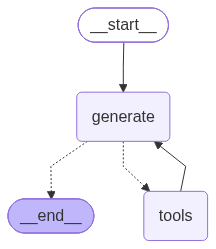

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass